# Q-Learning Grid World Assignment Part 1

The solution is divided into 4 sections, respectivily

**Section 0:** Setup and display the initial grid

**Section 1:** Plot the converged policy and value function for this grid world

**Section 2:** Do it for γ = 0.1, 0.5, and 0.9 (with epsilon = 0.1)

**Section 3:** For gamma = 0.9, plot the number of steps to reach the goal across episodes for epsilon = 0.1, 0.3, and 0.5


## Setup and Display Initial Grid


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from collections import deque

In [95]:
GRID_SIZE = 5

GOAL_STATE = [5, 5]
GOAL_REWARD = 5

TERMINAL_STATE = [3, 5]
TERMINAL_REWARD = -5

OBSTACLE_STATES = [[2, 2], [2, 4], [3, 1], [4, 3]]

BOUNDARY_REWARD = -1

NUM_EPISODES = 100000
MAX_STEPS = GRID_SIZE * GRID_SIZE * 10
LEARNING_RATE = 0.1 # constant learning rate
DISCOUNT_FACTOR = 0.9 # initial discount factor for future rewards
EPSILON = 0.1 # initial exploration rate

NUM_ACTIONS = 4
NUM_STATES = GRID_SIZE * GRID_SIZE

RANDOM_SEED = 88
np.random.seed(RANDOM_SEED)

In [96]:
def print_initial_grid():
    print("INITIAL GRID LAYOUT \n ")
    print(f"Grid Size: {GRID_SIZE}x{GRID_SIZE}")
    print(f"Start State (A): [1, 1] (top-left corner)")
    print(f"Goal State (G): {GOAL_STATE} (bottom-right corner)")
    print(f"Terminal State (T): {TERMINAL_STATE}")
    print(f"Obstacle States (X): {OBSTACLE_STATES}")
    print()
    
    print("Grid Layout (1-indexed coordinates):")
    print("   ", end="")
    for j in range(1, GRID_SIZE + 1):
        print(f"{j:2}", end=" ")
    print()
    
    for i in range(1, GRID_SIZE + 1):
        print(f"{i:2} ", end="")
        for j in range(1, GRID_SIZE + 1):
            current_pos = [i, j]
            if current_pos == [1, 1]:
                print(" A", end=" ")
            elif current_pos == GOAL_STATE:
                print(" G", end=" ")
            elif current_pos == TERMINAL_STATE:
                print(" T", end=" ")
            elif current_pos in OBSTACLE_STATES:
                print(" X", end=" ")
            else:
                print(" .", end=" ")
        print()
    print()
    print("Legend: A=Start, G=Goal, T=Terminal, X=Obstacle, .=Empty")
    print("="*50)

In [97]:
def plot_initial_grid():

    fig, ax = plt.subplots(figsize=(8, 8))
    
    for i in range(GRID_SIZE + 1):
        ax.plot([0, GRID_SIZE], [i, i], color='black', linewidth=1)
        ax.plot([i, i], [0, GRID_SIZE], color='black', linewidth=1)
    
    ax.plot([0, 0, GRID_SIZE, GRID_SIZE, 0], 
            [0, GRID_SIZE, GRID_SIZE, 0, 0], 
            color='red', linewidth=2.5)
    
    ax.plot(1 - 0.5, 1 - 0.5, 's', 
            markerfacecolor='#4B72B0', markersize=30, 
            markeredgecolor='navy', markeredgewidth=2)
    ax.text(1 - 0.5, 1 - 0.5, 'A', 
            color='white', fontsize=16, fontweight='bold', 
            ha='center', va='center')
    
    ax.plot(GOAL_STATE[1] - 0.5, GOAL_STATE[0] - 0.5, 's', 
            markerfacecolor='#2CA02C', markersize=30, 
            markeredgecolor='darkgreen', markeredgewidth=2)
    ax.text(GOAL_STATE[1] - 0.5, GOAL_STATE[0] - 0.5, 'G', 
            color='white', fontsize=16, fontweight='bold', 
            ha='center', va='center')
    
    ax.plot(TERMINAL_STATE[1] - 0.5, TERMINAL_STATE[0] - 0.5, 's', 
            markerfacecolor='#D62728', markersize=30, 
            markeredgecolor='darkred', markeredgewidth=2)
    ax.text(TERMINAL_STATE[1] - 0.5, TERMINAL_STATE[0] - 0.5, 'T', 
            color='white', fontsize=16, fontweight='bold', 
            ha='center', va='center')
    
    for obs in OBSTACLE_STATES:
        ax.add_patch(plt.Rectangle((obs[1] - 1, obs[0] - 1), 1, 1, color='black'))
    
    ax.plot([0, 0, GRID_SIZE, GRID_SIZE, 0], 
            [0, GRID_SIZE, GRID_SIZE, 0, 0], 
            color='red', linewidth=2.5)
    
    ax.set_xlim([-1, GRID_SIZE + 1])
    ax.set_ylim([GRID_SIZE + 1, -1])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    ax.set_title('Initial Environment', fontsize=15, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

INITIAL GRID LAYOUT 
 
Grid Size: 5x5
Start State (A): [1, 1] (top-left corner)
Goal State (G): [5, 5] (bottom-right corner)
Terminal State (T): [3, 5]
Obstacle States (X): [[2, 2], [2, 4], [3, 1], [4, 3]]

Grid Layout (1-indexed coordinates):
    1  2  3  4  5 
 1  A  .  .  .  . 
 2  .  X  .  X  . 
 3  X  .  .  .  T 
 4  .  .  X  .  . 
 5  .  .  .  .  G 

Legend: A=Start, G=Goal, T=Terminal, X=Obstacle, .=Empty


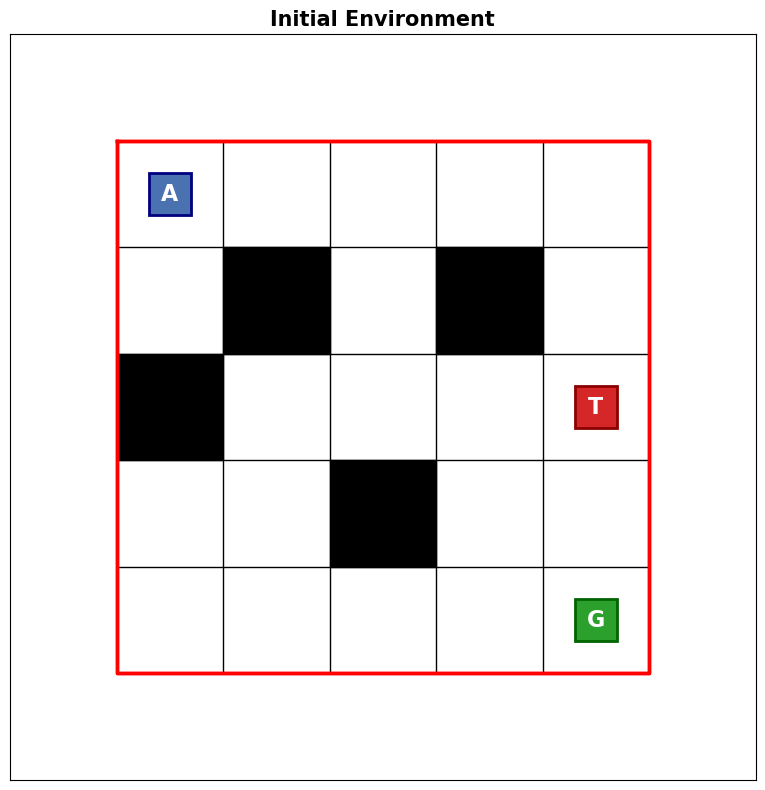

In [98]:
print_initial_grid()
plot_initial_grid()

## Helper Functions

In [99]:
def get_state(coordinates, size):
    return (coordinates[0] - 1) * size + coordinates[1]

def get_coordinates(state, size):
    return [(state - 1) // size + 1, (state - 1) % size + 1]

def is_valid_state(state, size, obstacles):
    if (1 <= state[0] <= size) and (1 <= state[1] <= size) and (state not in obstacles):
        return True
    return False

def is_terminal_state(state, goal, terminal):
    return state == goal or state == terminal

In [100]:
def step(current_state, action, size, goal, terminal, obstacles):
    if is_terminal_state(current_state, goal, terminal):
        return current_state, 0, True

    if action == 'N':
        next_state = [current_state[0] - 1, current_state[1]]
    elif action == 'S':
        next_state = [current_state[0] + 1, current_state[1]]
    elif action == 'E':
        next_state = [current_state[0], current_state[1] + 1]
    elif action == 'W':
        next_state = [current_state[0], current_state[1] - 1]
    else:
        raise ValueError("Invalid action")

    if is_valid_state(next_state, size, obstacles):
        if next_state == goal:
            return next_state, GOAL_REWARD, True
        elif next_state == terminal:
            return next_state, TERMINAL_REWARD, True
        else:
            return next_state, 0, False
    else:
        if (next_state[0] < 1) or (next_state[1] < 1) or (next_state[0] > size) or (next_state[1] > size):
            return current_state, BOUNDARY_REWARD, False
        else:
            return current_state, 0, False

### Q-Learning Algorithm

#### Q-Learning Parameters Summary

| Parameter | Symbol | Value | Purpose | Effect |
|-----------|--------|-------|---------|--------|
| **Discount Factor** | γ (gamma) | 0.9 | Controls how much **future rewards** are valued vs **immediate rewards** | • γ=0.1: Short-sighted (only immediate rewards matter)<br>• γ=0.9: Far-sighted (future rewards are important)<br>• γ=1.0: All future rewards equally valued |
| **Exploration Rate** | ε (epsilon) | 0.1 | Controls **exploration vs exploitation** during action selection | • ε=0.1: 10% random actions (exploration), 90% best action (exploitation)<br>• ε=0.5: 50% random, 50% best action<br>• Higher ε = more exploration |
| **Learning Rate** | α (alpha) | 0.1 | Controls **speed of Q-value updates** after each experience | • α=0.1: Slow, stable learning (10% update)<br>• α=0.9: Fast, unstable learning (90% update)<br>• Higher α = faster but noisier learning |

**Key Distinctions:**
- **Gamma (γ)**: Affects the **Q-learning update equation** - determines importance of future rewards
- **Epsilon (ε)**: Affects **action selection** - determines random vs greedy actions
- **Alpha (α)**: Affects **learning speed** - determines how much Q-values change per update

In [112]:
def run_q_learning(gamma, eps, num_eps=NUM_EPISODES):
    Q = 0.001 * np.random.rand(NUM_STATES, NUM_ACTIONS)
    
    steps_per_episode = []
    
    if num_eps >= 1000:
        progress_interval = min(10000, max(1, num_eps // 10))
    else:
        progress_interval = None
    
    for episode in range(num_eps):
    
        current_state = [1, 1]
        steps = 0
        
        for step_num in range(MAX_STEPS):
            current_state_idx = get_state(current_state, GRID_SIZE)
            
            if np.random.rand() < eps:
                action_idx = np.random.randint(NUM_ACTIONS)
            else:
                action_idx = np.argmax(Q[current_state_idx - 1, :])
            
            if action_idx == 0:
                action = 'N'
            elif action_idx == 1:
                action = 'S'
            elif action_idx == 2:
                action = 'E'
            else:
                action = 'W'
            
            next_state, reward, is_terminal = step(current_state, action, GRID_SIZE, 
                                                 GOAL_STATE, TERMINAL_STATE, OBSTACLE_STATES)
            next_state_idx = get_state(next_state, GRID_SIZE)
            
            Q[current_state_idx - 1, action_idx] += LEARNING_RATE * (
                reward + gamma * np.max(Q[next_state_idx - 1, :]) - Q[current_state_idx - 1, action_idx])
            
            current_state = next_state
            steps += 1
            
            if is_terminal:
                break
        
        steps_per_episode.append(steps)
        if progress_interval and (episode + 1) % progress_interval == 0:
            avg_recent_steps = np.mean(steps_per_episode[-progress_interval:]) if len(steps_per_episode) >= progress_interval else np.mean(steps_per_episode)
            print(f"    Episode {episode + 1}/{num_eps} - Avg steps (last {min(episode + 1, progress_interval)}): {avg_recent_steps:.2f}")
        
    
    return Q, steps_per_episode


## Section 1: Plot the Converged Policy and Value Function


In [102]:
def plot_converged_policy(Q, gamma, eps):

    policy = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = get_state([i + 1, j + 1], GRID_SIZE)
            best_action = np.argmax(Q[state - 1, :])
            policy[i, j] = best_action
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    action_symbols = ['↑', '↓', '→', '←']
    
    for i in range(GRID_SIZE + 1):
        ax.plot([0, GRID_SIZE], [i, i], color='black', linewidth=1)
        ax.plot([i, i], [0, GRID_SIZE], color='black', linewidth=1)
    
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            current_pos = [i + 1, j + 1]
            
            if current_pos == GOAL_STATE or current_pos == TERMINAL_STATE or current_pos in OBSTACLE_STATES:
                continue
            
            best_action = policy[i, j]
            ax.text(j + 0.5, i + 0.5, action_symbols[best_action], 
                   fontsize=20, ha='center', va='center', color='blue', fontweight='bold')
    
    ax.plot(1 - 0.5, 1 - 0.5, 's', 
           markerfacecolor='#4B72B0', markersize=25, 
           markeredgecolor='navy', markeredgewidth=2, alpha=0.3)
    ax.text(1 - 0.5, 1 - 0.5, 'A', 
           color='white', fontsize=12, fontweight='bold', ha='center', va='center')
    
    ax.plot(GOAL_STATE[1] - 0.5, GOAL_STATE[0] - 0.5, 's', 
           markerfacecolor='#2CA02C', markersize=25, 
           markeredgecolor='darkgreen', markeredgewidth=2, alpha=0.3)
    ax.text(GOAL_STATE[1] - 0.5, GOAL_STATE[0] - 0.5, 'G', 
           color='white', fontsize=12, fontweight='bold', ha='center', va='center')
    
    ax.plot(TERMINAL_STATE[1] - 0.5, TERMINAL_STATE[0] - 0.5, 's', 
           markerfacecolor='#D62728', markersize=25, 
           markeredgecolor='darkred', markeredgewidth=2, alpha=0.3)
    ax.text(TERMINAL_STATE[1] - 0.5, TERMINAL_STATE[0] - 0.5, 'T', 
           color='white', fontsize=12, fontweight='bold', ha='center', va='center')
    
    for obs in OBSTACLE_STATES:
        ax.add_patch(plt.Rectangle((obs[1] - 1, obs[0] - 1), 1, 1, color='black'))
    
    ax.plot([0, 0, GRID_SIZE, GRID_SIZE, 0], 
            [0, GRID_SIZE, GRID_SIZE, 0, 0], 
            color='red', linewidth=2.5)
    
    ax.set_xlim([-0.5, GRID_SIZE + 0.5])
    ax.set_ylim([GRID_SIZE + 0.5, -0.5])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    ax.set_title(f'Converged Policy (γ={gamma}, ε={eps})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Converged policy plotting function defined!


In [103]:
def plot_value_function(Q, gamma, eps):
    value_function = np.zeros((GRID_SIZE, GRID_SIZE))
    
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = get_state([i + 1, j + 1], GRID_SIZE)
            value_function[i, j] = np.max(Q[state - 1, :])
            if [i + 1, j + 1] == GOAL_STATE:
                value_function[i, j] = GOAL_REWARD
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    for i in range(GRID_SIZE + 1):
        ax.plot([0, GRID_SIZE], [i, i], color='black', linewidth=1)
        ax.plot([i, i], [0, GRID_SIZE], color='black', linewidth=1)
    
    vmin, vmax = np.min(value_function), np.max(value_function)
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.RdYlGn
    
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            current_pos = [i + 1, j + 1]
            
            if current_pos in OBSTACLE_STATES:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, color='black'))
                continue
            
            value = value_function[i, j]
            color = cmap(norm(value))
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color=color, alpha=0.7))
            ax.text(j + 0.5, i + 0.5, f'{value:.1f}', 
                   fontsize=10, ha='center', va='center', fontweight='bold')
    
    ax.plot([0, 0, GRID_SIZE, GRID_SIZE, 0], 
            [0, GRID_SIZE, GRID_SIZE, 0, 0], 
            color='red', linewidth=2.5)
    
    ax.set_xlim([-0.5, GRID_SIZE + 0.5])
    ax.set_ylim([GRID_SIZE + 0.5, -0.5])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    ax.set_title(f'Value Function (γ={gamma}, ε={eps})', fontsize=14, fontweight='bold')
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('State Value', fontsize=12)
    plt.tight_layout()
    plt.show()

Value function plotting function defined!


=== SECTION 1: CONVERGED POLICY AND VALUE FUNCTION ===
Running Q-learning with default parameters...
Gamma: 0.9, Epsilon: 0.1, Learning Rate: 0.1
  Episode 10000/100000 - Avg steps (last 10000): 9.06
  Episode 10000/100000 - Avg steps (last 10000): 9.06
  Episode 20000/100000 - Avg steps (last 10000): 8.87
  Episode 20000/100000 - Avg steps (last 10000): 8.87
  Episode 30000/100000 - Avg steps (last 10000): 8.87
  Episode 30000/100000 - Avg steps (last 10000): 8.87
  Episode 40000/100000 - Avg steps (last 10000): 8.85
  Episode 40000/100000 - Avg steps (last 10000): 8.85
  Episode 50000/100000 - Avg steps (last 10000): 8.86
  Episode 50000/100000 - Avg steps (last 10000): 8.86
  Episode 60000/100000 - Avg steps (last 10000): 8.85
  Episode 60000/100000 - Avg steps (last 10000): 8.85
  Episode 70000/100000 - Avg steps (last 10000): 8.86
  Episode 70000/100000 - Avg steps (last 10000): 8.86
  Episode 80000/100000 - Avg steps (last 10000): 8.84
  Episode 80000/100000 - Avg steps (last 100

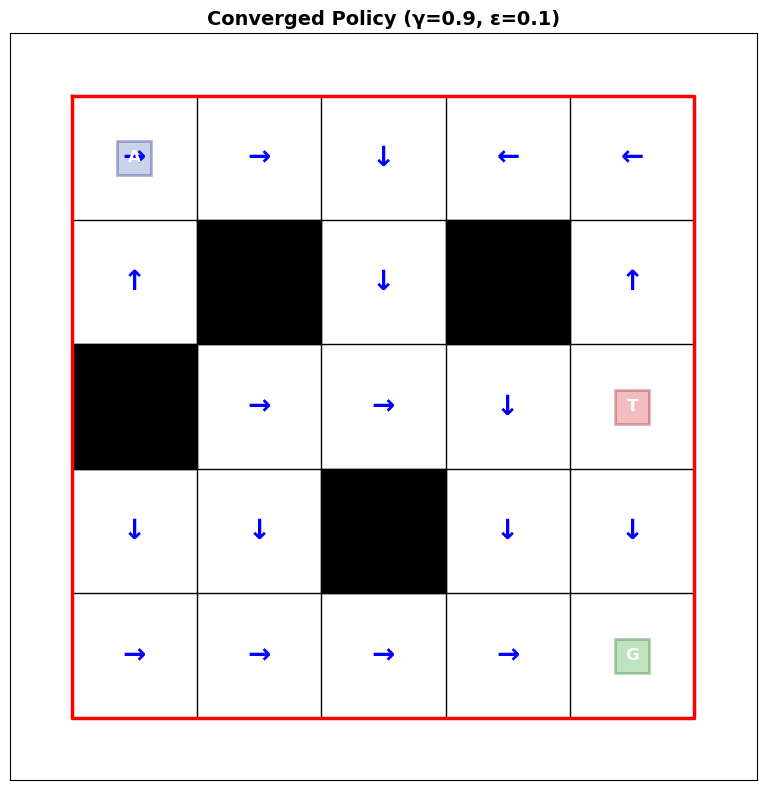

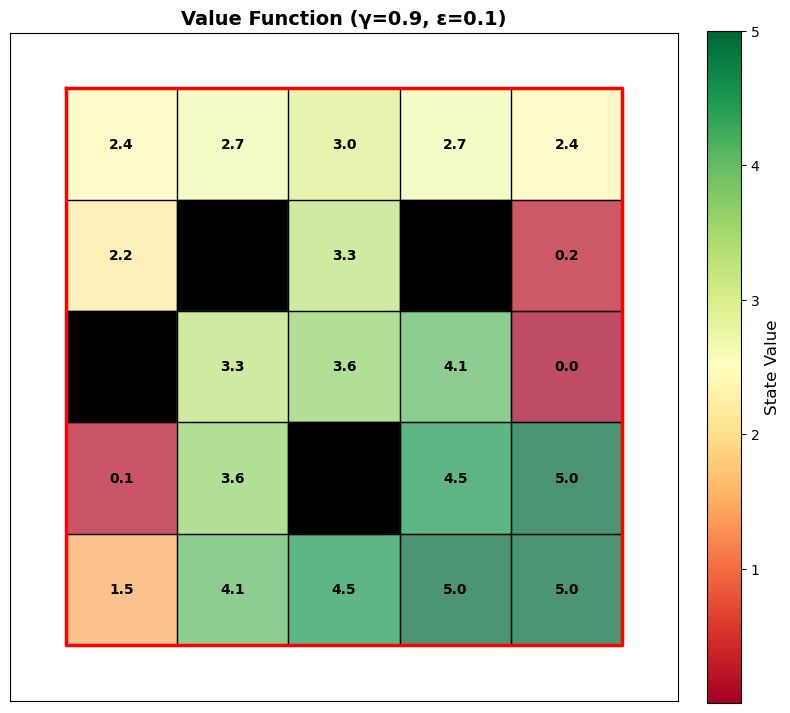

In [104]:
print(f"Gamma: {DISCOUNT_FACTOR}, Epsilon: {EPSILON}, Learning Rate: {LEARNING_RATE}")

final_q_table, _ = run_q_learning(DISCOUNT_FACTOR, EPSILON)

plot_converged_policy(final_q_table, DISCOUNT_FACTOR, EPSILON)
plot_value_function(final_q_table, DISCOUNT_FACTOR, EPSILON)

## Section 2: Constant Epsilon and Variable Gamma

For ε = 0.1 and different values of γ = 0.1, 0.5, 0.9

=== SECTION 3: POLICY AND VALUE FUNCTION FOR DIFFERENT GAMMA VALUES ===

Training for: Gamma=0.1, Epsilon=0.1
  Episode 10000/100000 - Avg steps (last 10000): 8.97
  Episode 10000/100000 - Avg steps (last 10000): 8.97
  Episode 20000/100000 - Avg steps (last 10000): 8.85
  Episode 20000/100000 - Avg steps (last 10000): 8.85
  Episode 30000/100000 - Avg steps (last 10000): 8.84
  Episode 30000/100000 - Avg steps (last 10000): 8.84
  Episode 40000/100000 - Avg steps (last 10000): 8.85
  Episode 40000/100000 - Avg steps (last 10000): 8.85
  Episode 50000/100000 - Avg steps (last 10000): 8.88
  Episode 50000/100000 - Avg steps (last 10000): 8.88
  Episode 60000/100000 - Avg steps (last 10000): 8.84
  Episode 60000/100000 - Avg steps (last 10000): 8.84
  Episode 70000/100000 - Avg steps (last 10000): 8.84
  Episode 70000/100000 - Avg steps (last 10000): 8.84
  Episode 80000/100000 - Avg steps (last 10000): 8.85
  Episode 80000/100000 - Avg steps (last 10000): 8.85
  Episode 90000/100000 - A

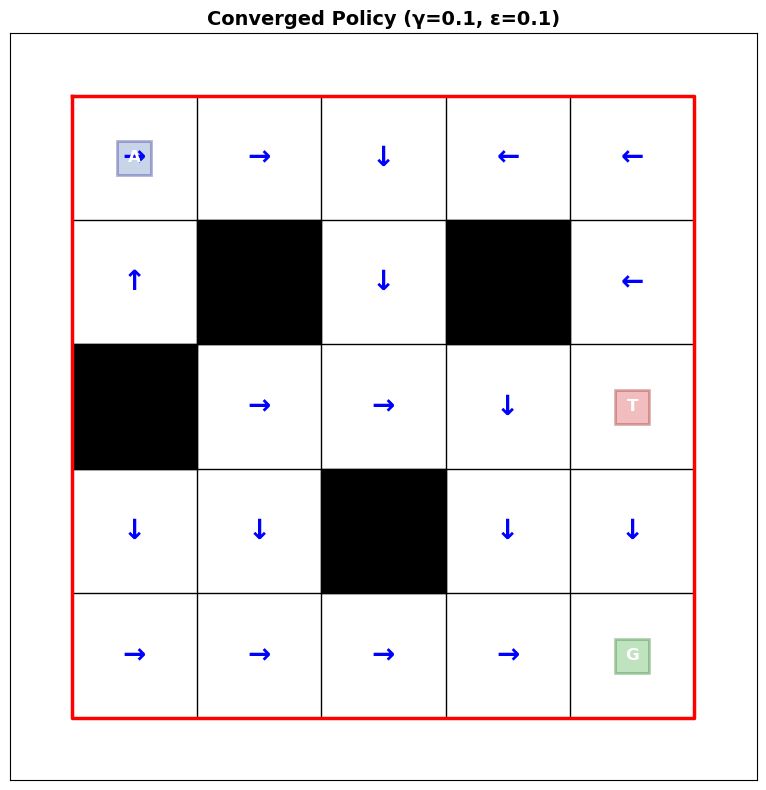

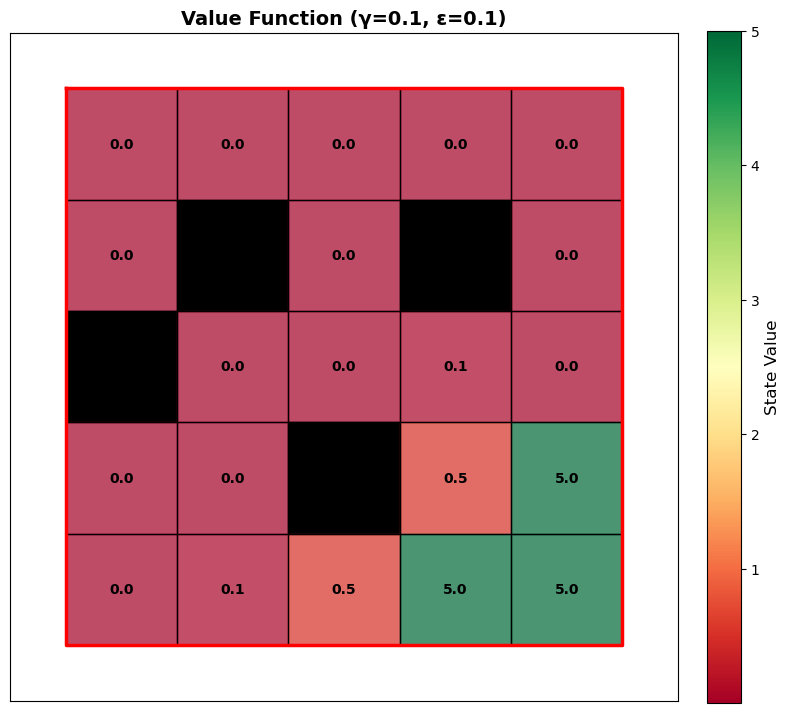


Training for: Gamma=0.5, Epsilon=0.1
  Episode 10000/100000 - Avg steps (last 10000): 9.13  Episode 10000/100000 - Avg steps (last 10000): 9.13

  Episode 20000/100000 - Avg steps (last 10000): 8.87
  Episode 20000/100000 - Avg steps (last 10000): 8.87
  Episode 30000/100000 - Avg steps (last 10000): 8.87
  Episode 30000/100000 - Avg steps (last 10000): 8.87
  Episode 40000/100000 - Avg steps (last 10000): 8.86
  Episode 40000/100000 - Avg steps (last 10000): 8.86
  Episode 50000/100000 - Avg steps (last 10000): 8.86
  Episode 50000/100000 - Avg steps (last 10000): 8.86
  Episode 60000/100000 - Avg steps (last 10000): 8.88
  Episode 60000/100000 - Avg steps (last 10000): 8.88
  Episode 70000/100000 - Avg steps (last 10000): 8.87
  Episode 70000/100000 - Avg steps (last 10000): 8.87
  Episode 80000/100000 - Avg steps (last 10000): 8.87
  Episode 80000/100000 - Avg steps (last 10000): 8.87
  Episode 90000/100000 - Avg steps (last 10000): 8.85
  Episode 90000/100000 - Avg steps (last 100

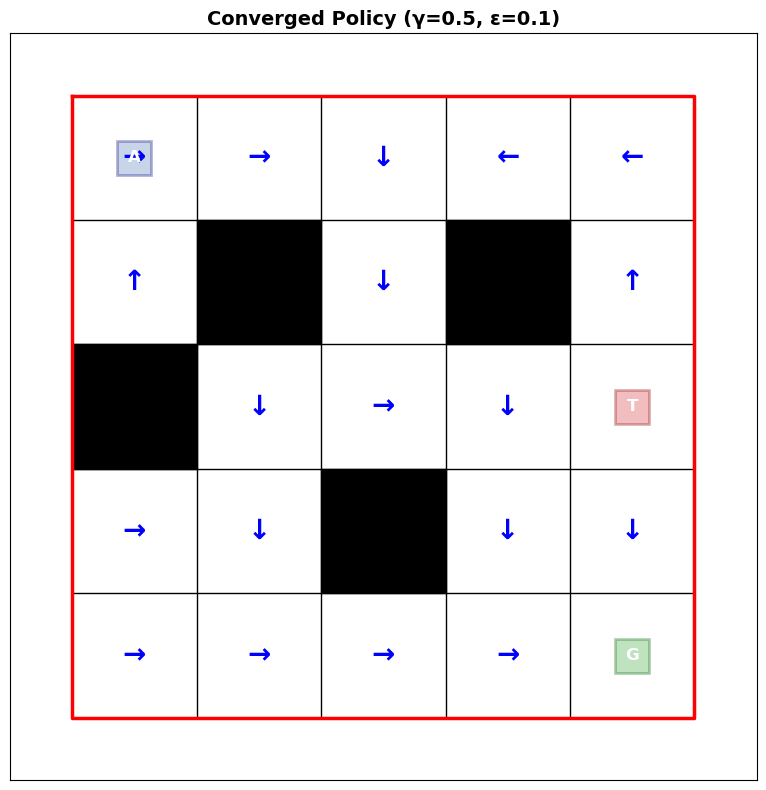

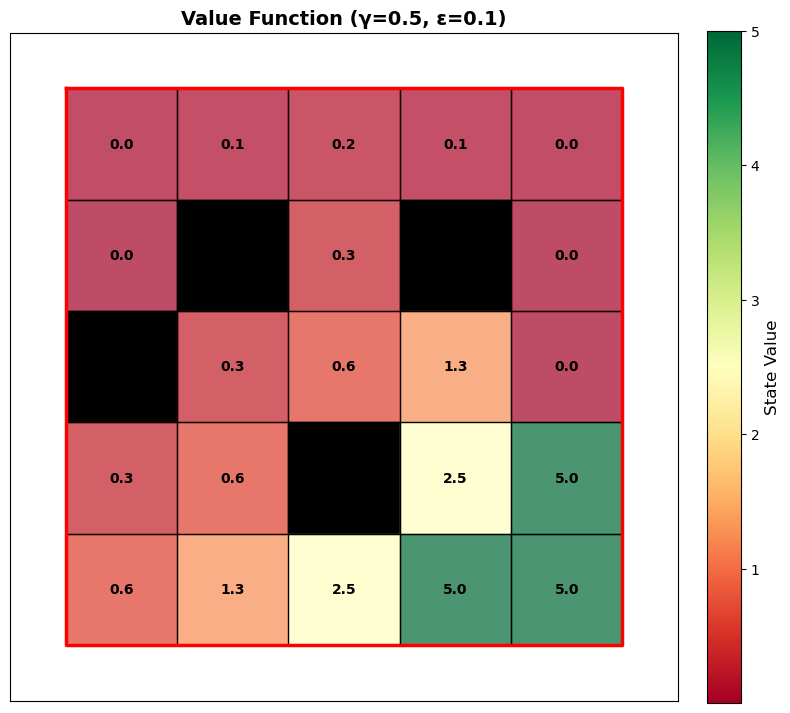


Training for: Gamma=0.9, Epsilon=0.1
  Episode 10000/100000 - Avg steps (last 10000): 9.20
  Episode 10000/100000 - Avg steps (last 10000): 9.20
  Episode 20000/100000 - Avg steps (last 10000): 8.84
  Episode 20000/100000 - Avg steps (last 10000): 8.84
  Episode 30000/100000 - Avg steps (last 10000): 8.87
  Episode 30000/100000 - Avg steps (last 10000): 8.87
  Episode 40000/100000 - Avg steps (last 10000): 8.86
  Episode 40000/100000 - Avg steps (last 10000): 8.86
  Episode 50000/100000 - Avg steps (last 10000): 8.86
  Episode 60000/100000 - Avg steps (last 10000): 8.87
  Episode 50000/100000 - Avg steps (last 10000): 8.86
  Episode 60000/100000 - Avg steps (last 10000): 8.87
  Episode 70000/100000 - Avg steps (last 10000): 8.90
  Episode 70000/100000 - Avg steps (last 10000): 8.90
  Episode 80000/100000 - Avg steps (last 10000): 8.85
  Episode 80000/100000 - Avg steps (last 10000): 8.85
  Episode 90000/100000 - Avg steps (last 10000): 8.85
  Episode 90000/100000 - Avg steps (last 100

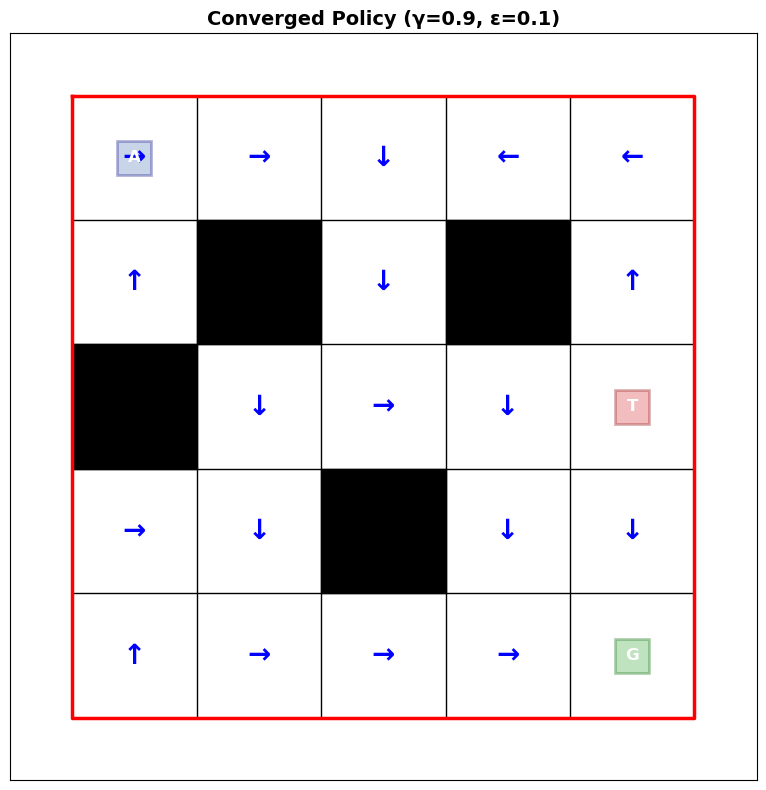

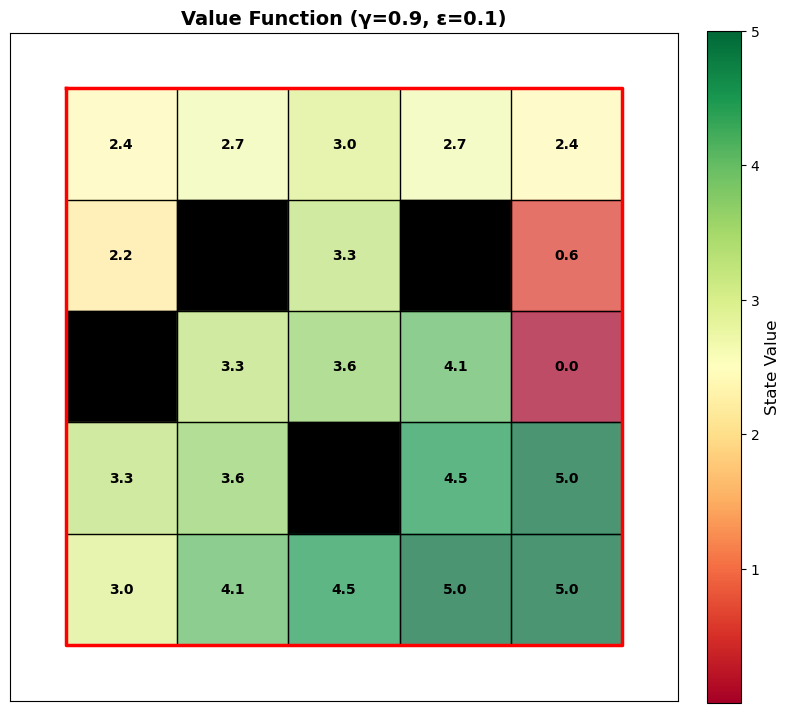

In [105]:
gammas = [0.1, 0.5, 0.9]
epsilon_const = 0.1

for gamma in gammas:
    print(f"\nTraining for: Gamma={gamma}, Epsilon={epsilon_const}")
    
    final_q_table, _ = run_q_learning(gamma, epsilon_const)
    
    plot_converged_policy(final_q_table, gamma, epsilon_const)
    plot_value_function(final_q_table, gamma, epsilon_const)

## Section 3: Constant Gamma and Variable Epsilon

For γ = 0.9 and different values of ε = 0.1, 0.3, 0.5

In [108]:
def plot_learning_curve(all_steps_data, gamma):
    plt.figure(figsize=(8, 5))
    for eps, steps_runs in all_steps_data.items():
        steps_runs = np.array(steps_runs)  # shape: (num_runs, num_episodes)
        avg_steps = np.mean(steps_runs, axis=0)
        std_steps = np.std(steps_runs, axis=0)
        episodes = np.arange(1, len(avg_steps) + 1)
        log_episodes = np.log(episodes)
        plt.plot(log_episodes, avg_steps, label=f'ε={eps}')
        plt.fill_between(log_episodes, avg_steps - std_steps, avg_steps + std_steps, alpha=0.2)
    plt.xlabel('log(Episode)')
    plt.ylabel('Average Steps to Goal')
    plt.title(f'Learning Curve (gamma={gamma})')
    plt.legend()
    plt.grid(True)
    plt.show()


Training for: Gamma=0.9, Epsilon=0.1

  Run 1/20:
  Episode 10000/100000 - Avg steps (last 10000): 9.03
  Episode 10000/100000 - Avg steps (last 10000): 9.03
  Episode 20000/100000 - Avg steps (last 10000): 8.84
  Episode 20000/100000 - Avg steps (last 10000): 8.84
  Episode 30000/100000 - Avg steps (last 10000): 8.86
  Episode 30000/100000 - Avg steps (last 10000): 8.86
  Episode 40000/100000 - Avg steps (last 10000): 8.87
  Episode 40000/100000 - Avg steps (last 10000): 8.87
  Episode 50000/100000 - Avg steps (last 10000): 8.87
  Episode 50000/100000 - Avg steps (last 10000): 8.87
  Episode 60000/100000 - Avg steps (last 10000): 8.86
  Episode 60000/100000 - Avg steps (last 10000): 8.86
  Episode 70000/100000 - Avg steps (last 10000): 8.85
  Episode 80000/100000 - Avg steps (last 10000): 8.85
  Episode 70000/100000 - Avg steps (last 10000): 8.85
  Episode 80000/100000 - Avg steps (last 10000): 8.85
  Episode 90000/100000 - Avg steps (last 10000): 8.87
  Episode 90000/100000 - Avg st

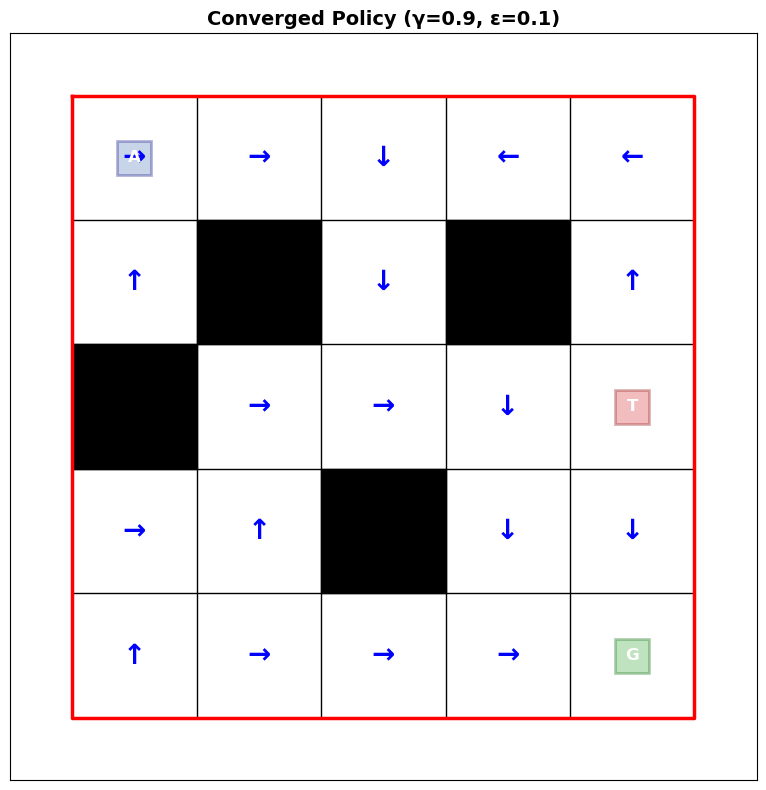

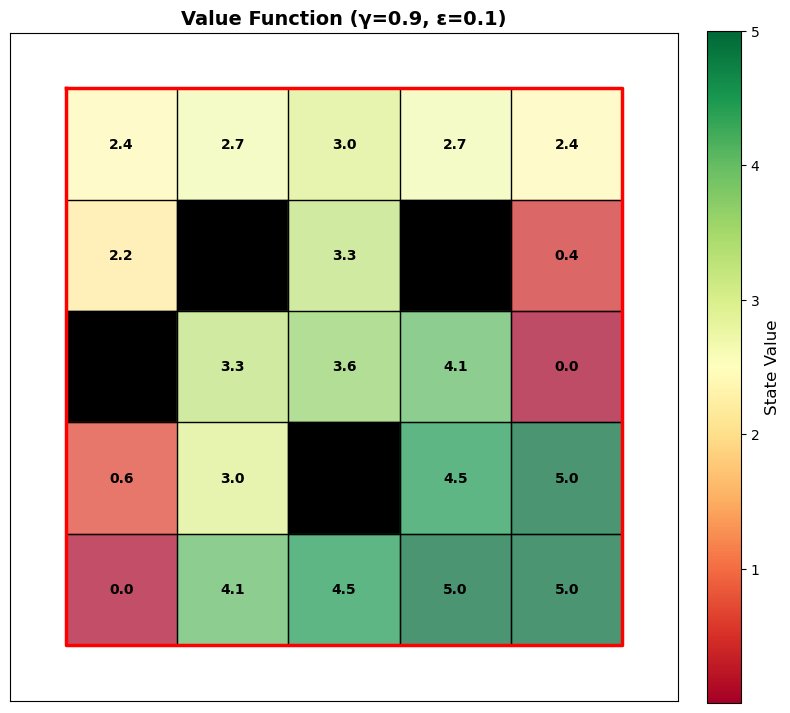


Training for: Gamma=0.9, Epsilon=0.3

  Run 1/20:
  Episode 10000/100000 - Avg steps (last 10000): 11.38
  Episode 10000/100000 - Avg steps (last 10000): 11.38
  Episode 20000/100000 - Avg steps (last 10000): 11.25
  Episode 20000/100000 - Avg steps (last 10000): 11.25
  Episode 30000/100000 - Avg steps (last 10000): 11.28
  Episode 30000/100000 - Avg steps (last 10000): 11.28
  Episode 40000/100000 - Avg steps (last 10000): 11.27
  Episode 40000/100000 - Avg steps (last 10000): 11.27
  Episode 50000/100000 - Avg steps (last 10000): 11.30
  Episode 50000/100000 - Avg steps (last 10000): 11.30
  Episode 60000/100000 - Avg steps (last 10000): 11.25
  Episode 60000/100000 - Avg steps (last 10000): 11.25
  Episode 70000/100000 - Avg steps (last 10000): 11.27
  Episode 70000/100000 - Avg steps (last 10000): 11.27
  Episode 80000/100000 - Avg steps (last 10000): 11.32
  Episode 80000/100000 - Avg steps (last 10000): 11.32
  Episode 90000/100000 - Avg steps (last 10000): 11.29
  Episode 9000

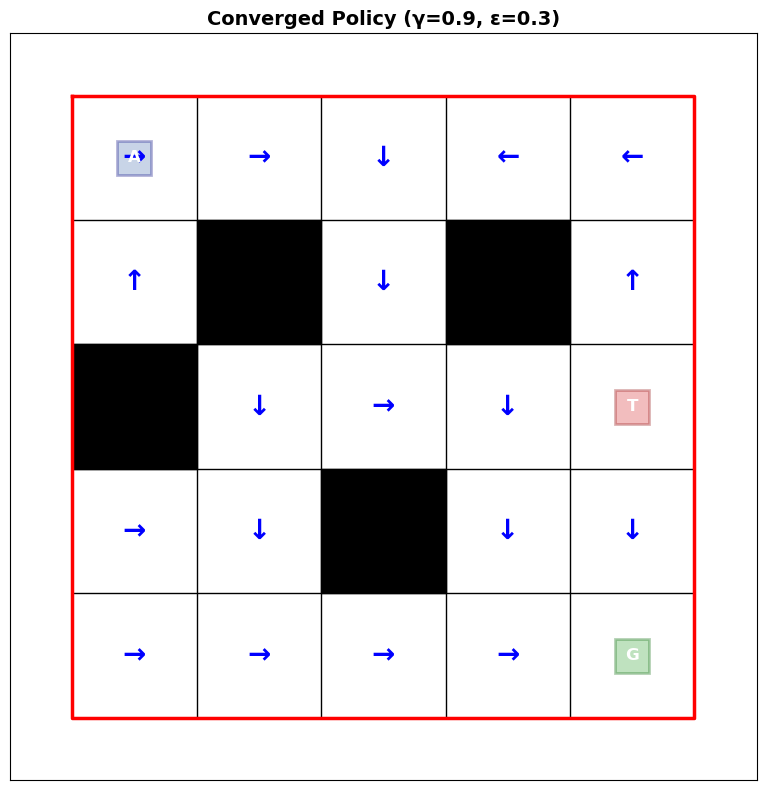

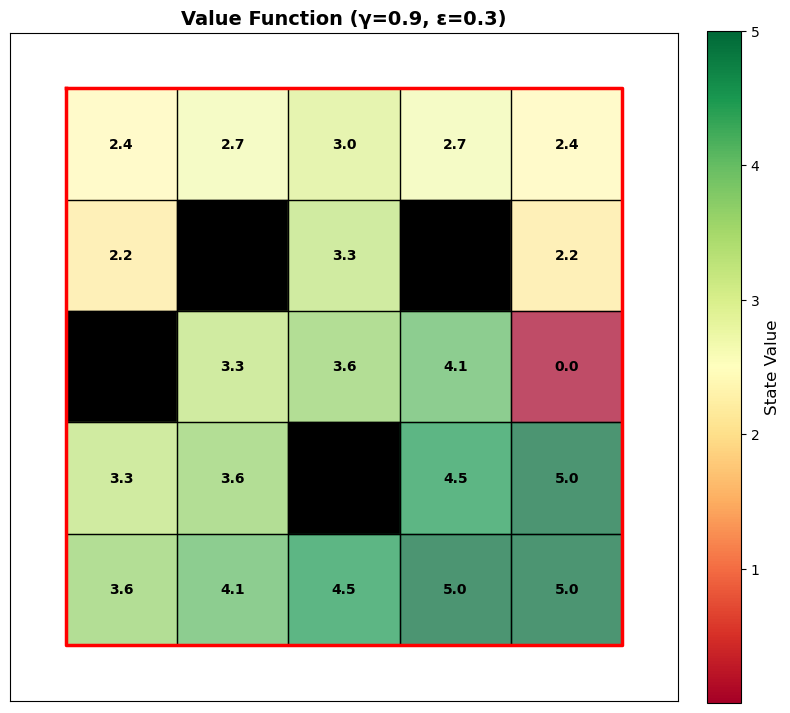


Training for: Gamma=0.9, Epsilon=0.5

  Run 1/20:
  Episode 10000/100000 - Avg steps (last 10000): 16.03
  Episode 10000/100000 - Avg steps (last 10000): 16.03
  Episode 20000/100000 - Avg steps (last 10000): 15.72
  Episode 20000/100000 - Avg steps (last 10000): 15.72
  Episode 30000/100000 - Avg steps (last 10000): 15.79
  Episode 30000/100000 - Avg steps (last 10000): 15.79
  Episode 40000/100000 - Avg steps (last 10000): 15.71
  Episode 40000/100000 - Avg steps (last 10000): 15.71
  Episode 50000/100000 - Avg steps (last 10000): 15.74
  Episode 50000/100000 - Avg steps (last 10000): 15.74
  Episode 60000/100000 - Avg steps (last 10000): 15.77
  Episode 60000/100000 - Avg steps (last 10000): 15.77
  Episode 70000/100000 - Avg steps (last 10000): 15.71
  Episode 70000/100000 - Avg steps (last 10000): 15.71
  Episode 80000/100000 - Avg steps (last 10000): 15.73
  Episode 80000/100000 - Avg steps (last 10000): 15.73
  Episode 90000/100000 - Avg steps (last 10000): 15.76
  Episode 9000

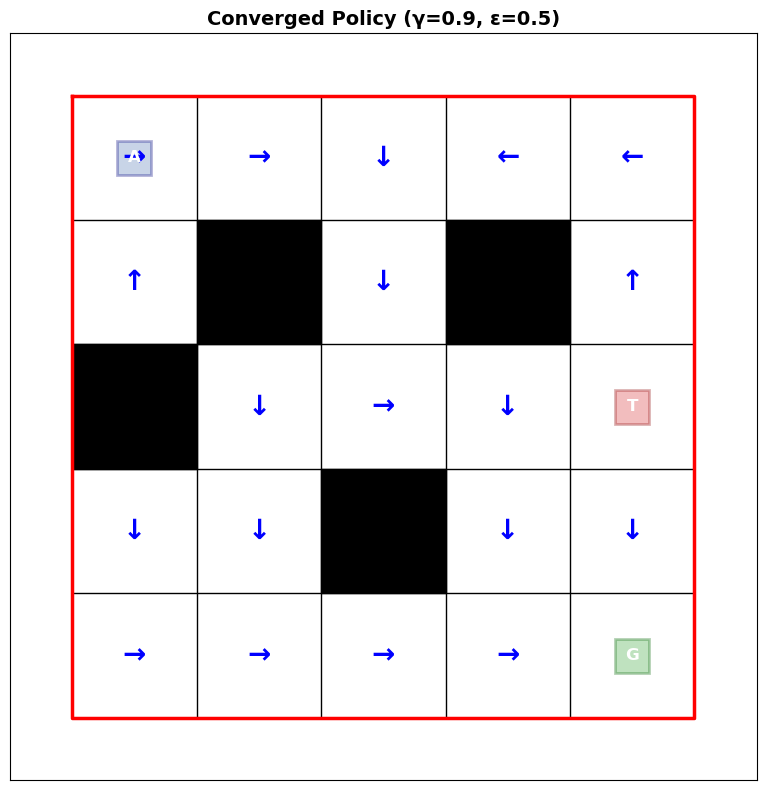

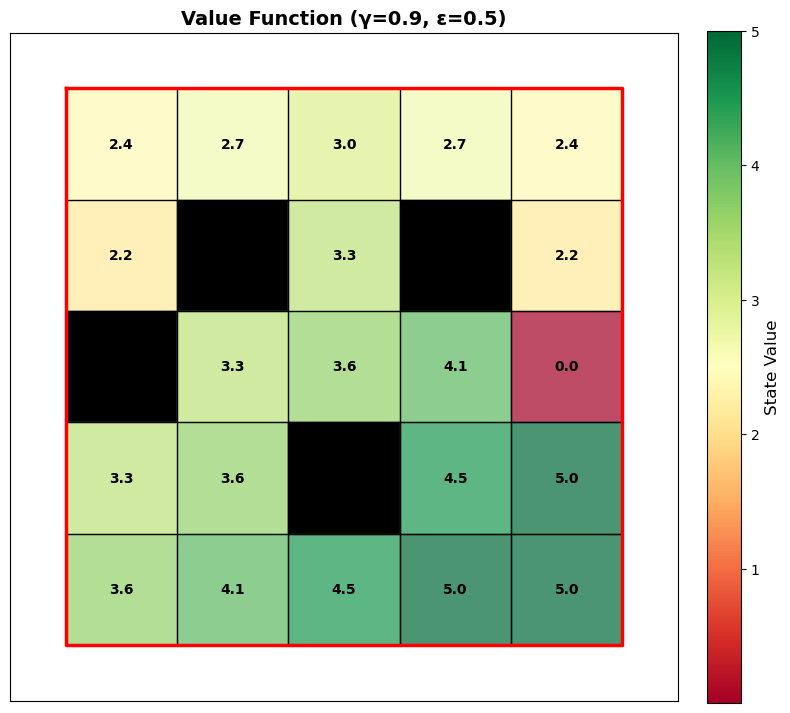

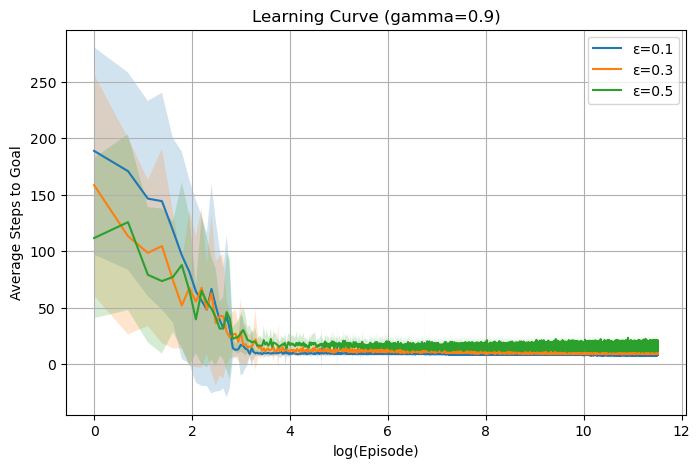

In [111]:
epsilons = [0.1, 0.3, 0.5]
gamma_const = 0.9
num_runs = 20  # Number of runs for averaging
all_steps_data = {}

for eps in epsilons:
    print(f"\nTraining for: Gamma={gamma_const}, Epsilon={eps}")
    steps_runs = []
    final_q_table = None
    for run in range(num_runs):
        print(f"\n  Run {run + 1}/{num_runs}:")
        q_table, steps_list = run_q_learning(gamma_const, eps)
        steps_runs.append(steps_list)
        if run == 0:
            final_q_table = q_table
    steps_runs = np.array(steps_runs)
    all_steps_data[eps] = steps_runs
    
    # Print statistics for the last run
    print(f"\n📊 Episode Statistics for ε={eps} (last run):")
    print(f"  • Total Episodes: {len(steps_list)}")
    print(f"  • Mean Steps: {np.mean(steps_list):.2f}")
    print(f"  • Std Dev: {np.std(steps_list):.2f}")
    print(f"  • Min Steps: {np.min(steps_list)} (Episode {np.argmin(steps_list) + 1})")
    print(f"  • Max Steps: {np.max(steps_list)} (Episode {np.argmax(steps_list) + 1})")
    print(f"  • First 5 Episodes: {steps_list[:5]}")
    print(f"  • Last 5 Episodes: {steps_list[-5:]}")

    plot_converged_policy(final_q_table, gamma_const, eps)
    plot_value_function(final_q_table, gamma_const, eps)
    

plot_learning_curve(all_steps_data, gamma_const)